In [29]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings("ignore")

import sys
import os

sys.path.append(os.path.abspath('../Pathfinder'))

from helper_functions import *
from radar_functions import *
from pathfinder import *
from attach_grounddata import *
from add_dataflashlog import *
from clicki_tool import *


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
datasetID = '26_04_2024_5'
campaignID = '2024_SIOS'
RADAR = load_RADAR(radar_type='UWiBaSS', datasetID=datasetID, campaignID=campaignID)

Dataset 26_04_2024_5 from campaign 2024_SIOS is loaded from /Volumes/PortableSSD/SnowDrone/UWiBaSS/26_04_2024_5/uwibass_object.pkl


In [31]:

# Setting the Pathfinder parameters
PF_parameters = {
    'a': 1,         #weight of radar image in cost function
    'b': 1,         #weight of (hessian) ridges in cost function
    'c': 2,         #weight of peak prominance in cost function
    'd': 2,         #weight of the localized cross-correlation 
    'db': 0,        #depth bias term (used to have a bias towards top for top layer, bottom for bottom layer)
    'sigma': 1,     #for blurring the cost map, 1 = no blurring
    'jumpiness': 2  #vertical freedom for the pathfinder (larger jumps are penalized)
    }

# Does RADAR have flightstate data?
has_flightstate = True

# Does RADAR have geolocation data?
has_geolocation = True

# Is there in-situ data (probe/ snow profile) that you want to add? Could be for validation or to view in the clicki_tool later
add_insitu_data = True
#TODO even if add_insitu_data = False, we need to add the eps_r + uncertainty! Best derived by providing a density?

# This is a UWiBaSS specific flag. Auxilliary data is added from the ardupilot dataflashlogs and some processing is done there
check_dataflashlog = False 

#TODO: Even if add_insitu_data = False, we return the 4 vars, this is of course not nice and pretty much unintuitive
RADAR, df_MP, df_SP, dict_SP = populate_datafields(RADAR,
                                     PF_parameters=PF_parameters,
                                     has_flightstate=has_flightstate,
                                     has_geolocation=has_geolocation,
                                     add_insitu_data=add_insitu_data,
                                     check_dataflashlog=check_dataflashlog,
                                     )

Co-locating in-situ data to radar footprints..


In [32]:
# section = RADAR.rx_rpca[:, :].copy()
    
first_layer = 'top' if RADAR.target_type == 'terrestrial_snow' else 'bottom' # or  RADAR.target_type == 'unknown'
second_layer = 'bottom' if first_layer == 'top' else 'top'


first_cost, first_partial_costs = compute_cost_map(RADAR.rx_rpca[:, :],
                                                   RADAR.PF_parameters,
                                                   layer=first_layer,
                                                   first_layer=first_layer,
                                                   debug=True
                                                   )

second_cost, second_partial_costs = compute_next_cost_map(RADAR.rx_rpca[:, :],
                                                          RADAR.PF_parameters, 
                                                          layer=second_layer,
                                                          first_layer=first_layer,
                                                          first_reflection_cost=first_partial_costs['reflection'],
                                                          first_ridge_cost=first_partial_costs['ridge'],
                                                          first_continuity_cost=first_partial_costs['continuity'],
                                                          debug=True
                                                          )

unbiased_cost = compute_next_cost_map(RADAR.rx_rpca[:, :],
                                      RADAR.PF_parameters,
                                      layer=None,
                                      first_layer=None,
                                      first_reflection_cost=first_partial_costs['reflection'],
                                      first_ridge_cost=first_partial_costs['ridge'],
                                      first_continuity_cost=first_partial_costs['continuity'],
                                      debug=False
                                      )

# We can save the first cost map already.
# Since the first path will be masked in the second cost map, we save the second later.
cost_maps = {}
cost_maps[first_layer] = first_cost
cost_maps['unbiased'] = unbiased_cost

In [33]:
# DEPLOYING THE PATHFINDER AND DOING PATH REINEMENT
paths = {}

#find first path/layer
path, path_cost = find_optimal_path(cost_maps[first_layer], 
                                    PF_parameters,
                                    layer=first_layer,
                                    )
py_first, px_first  = list(zip(*path))
paths[first_layer] = np.array(list(py_first))


# masking the first found path in the cost map
second_cost = mask_path_in_cost(second_cost, path, radius=3, strength=.5)
cost_maps[second_layer] = second_cost

#find second path/layer
path2, path_cost2 = find_optimal_path(cost_maps[second_layer], 
                                    PF_parameters,
                                    layer=second_layer
                                    )

py_second, px_second  = list(zip(*path2))
paths[second_layer] = np.array(list(py_second))

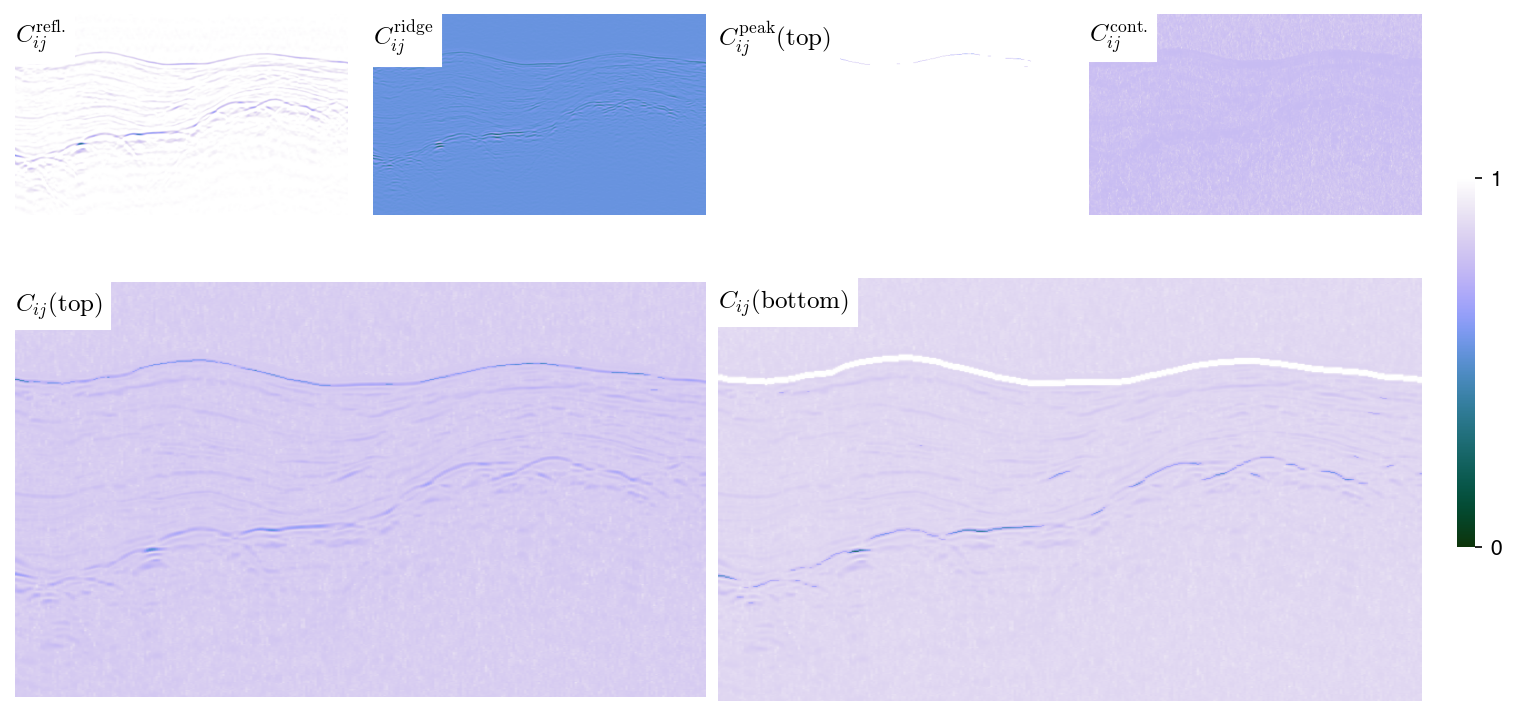

In [ ]:

from matplotlib.gridspec import GridSpec
startind = 2000
endind = 12000
props = dict(boxstyle='square', facecolor='white', edgecolor='white')

fig = plt.figure(figsize=(10, 5), constrained_layout=True, dpi=150)
gs = GridSpec(2, 4, figure=fig, height_ratios=[.5, 1])

ax_top_cost = fig.add_subplot(gs[1, 0:2])
ax_top_cost.axis('off')
ax_top_cost.text(0.0, 0.98, '$C_{ij}(\mathrm{top})$', transform=ax_top_cost.transAxes, fontsize=12,
        va='top', ha='left', bbox=props)

ax_bottom_cost = fig.add_subplot(gs[1, 2:4])
ax_bottom_cost.axis('off')
ax_bottom_cost.text(0.0, 0.98, '$C_{ij}(\mathrm{bottom})$', transform=ax_bottom_cost.transAxes, fontsize=12,
        va='top', ha='left', bbox=props)

imsh = ax_top_cost.imshow(first_cost[50:-100, startind:endind][:, 2700:3000], aspect=.5, vmin=0, vmax=1, cmap=cmr.horizon)
imsh1 = ax_bottom_cost.imshow(second_cost[50:-100, startind:endind][:, 2700:3000], aspect=.5, vmin=0, vmax=1, cmap=cmr.horizon)
# imsh1.cmap.set_over((1, 0, 0, .25))

ax_reflection_cost = fig.add_subplot(gs[0, 0])
ax_reflection_cost.axis('off')
ax_reflection_cost.text(0.0, 0.98, '$C^{\mathrm{refl.}}_{ij}$', transform=ax_reflection_cost.transAxes, fontsize=12,
        va='top', ha='left', bbox=props)
ax_reflection_cost.imshow(first_partial_costs['reflection'][50:-100, startind:endind][:, 2700:3000],
                     aspect=.5, cmap=cmr.horizon,
                     vmin=0, vmax=1
                     )

ax_ridge_cost = fig.add_subplot(gs[0, 1])
ax_ridge_cost.axis('off')
ax_ridge_cost.text(0.0, 0.98, '$C^{\mathrm{ridge}}_{ij}$', transform=ax_ridge_cost.transAxes, fontsize=12,
        va='top', ha='left', bbox=props)
ax_ridge_cost.imshow(first_partial_costs['ridge'][50:-100, startind:endind][:, 2700:3000],
                     aspect=.5, cmap=cmr.horizon,
                     vmin=0, vmax=1
                     )
ax_peak1_cost = fig.add_subplot(gs[0, 2])
ax_peak1_cost.axis('off')
ax_peak1_cost.text(0.0, 0.98, '$C^{\mathrm{peak}}_{ij}(\mathrm{top})$', transform=ax_peak1_cost.transAxes, fontsize=12,
        va='top', ha='left', bbox=props)
imsh1= ax_peak1_cost.imshow(first_partial_costs['peak'][50:-100, startind:endind][:, 2700:3000],
                     aspect=.5, cmap=cmr.horizon,
                     vmin=0, vmax=1
                     )
# fig.colorbar(imsh1, ax=[ax_peak1_cost], orientation='horizontal',
#             label='Cost value', ticks=[-0.75, 0, 0.75], location='top')

ax_cont_cost = fig.add_subplot(gs[0, 3])
ax_cont_cost.axis('off')
ax_cont_cost.text(0.0, 0.98, '$C^{\mathrm{cont.}}_{ij}$', transform=ax_cont_cost.transAxes, fontsize=12,
        va='top', ha='left', bbox=props)
ax_cont_cost.imshow(first_partial_costs['continuity'][50:-100, startind:endind][:, 2700:3000],
                     aspect=.5, cmap=cmr.horizon,
                     vmin=0, vmax=1
                     )

cbar = fig.colorbar(imsh1, ax=[ax_bottom_cost, ax_cont_cost], orientation='vertical', shrink=.5,
        ticks=[0, 1])
cbar.outline.set_visible(False)

fig.savefig('./export/fig05.pdf', format='pdf', dpi=600)
fig.savefig('./export/fig05.png', dpi=600)
